# K-Means Assumptions and Model Fit

This notebook reproduces the official scikit-learn demonstration of situations in which K-Means can produce unexpected or misleading clusters.

The notebook creates four synthetic datasets and examines the effect of:

1. Selecting an incorrect number of clusters.
2. Applying K-Means to elongated or anisotropic clusters.
3. Applying K-Means to clusters with unequal variance.
4. Applying K-Means to clusters with highly unequal sample sizes.
5. Increasing the number of centroid initializations.
6. Using Gaussian Mixture Models for more flexible cluster shapes.

The notebook also calculates clustering evaluation metrics and saves all important plots and numerical results.

Plots are saved in:

`root_folder/plots/kmeans_assumptions`

Results are saved in:

`root_folder/results/kmeans_assumptions`

### Import the Required Libraries

This section imports the libraries required for:

- Path and folder management
- Numerical computation
- Tabular result management
- Synthetic dataset generation
- K-Means clustering
- Gaussian Mixture Models
- Cluster evaluation
- Data visualization

In [1]:
from pathlib import Path
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.mixture import GaussianMixture

##### Explanation :
The notebook uses:

- `NumPy` for numerical operations
- `Pandas` for result tables
- `Matplotlib` for plotting
- `KMeans` for centroid-based clustering
- `GaussianMixture` as an alternative clustering model
- Multiple clustering metrics for quantitative evaluation

### Define the Project Folders

The notebook is expected to be located inside:

`root_folder/notebooks/03_kmeans_assumptions.ipynb`

Therefore, the project root folder is identified as the parent of the `notebooks` folder.

The required plot and result folders are then created automatically if they do not already exist.

In [2]:
def find_project_root(start_path):
    """
    Find the main project folder containing:
    data/, notebooks/, plots/, and results/.
    """
    start_path = Path(start_path).resolve()

    for folder in [start_path, *start_path.parents]:
        required_folders = [
            folder / "data",
            folder / "notebooks",
            folder / "plots",
            folder / "results",
        ]

        if all(path.is_dir() for path in required_folders):
            return folder

    raise FileNotFoundError(
        "Project root could not be found. "
        "Make sure data, notebooks, plots, and results folders exist."
    )


# Find the main project folder
ROOT_DIR = find_project_root(Path.cwd())

# Notebook location
NOTEBOOK_DIR = ROOT_DIR / "notebooks" / "module_2"

NOTEBOOK_PATH = (
    NOTEBOOK_DIR
    / "02_kmeans_assumptions.ipynb"
)

# Output folders for this notebook
PLOTS_DIR = (
    ROOT_DIR
    / "plots"
    / "kmeans_assumptions"
)

RESULTS_DIR = (
    ROOT_DIR
    / "results"
    / "kmeans_assumptions"
)

# Create output folders if they do not exist
PLOTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Display the folder paths
print("=" * 80)
print("PROJECT FOLDER PATHS")
print("=" * 80)
print(f"Project root   : {ROOT_DIR}")
print(f"Notebook folder: {NOTEBOOK_DIR}")
print(f"Notebook path  : {NOTEBOOK_PATH}")
print(f"Plots folder   : {PLOTS_DIR}")
print(f"Results folder : {RESULTS_DIR}")
print("=" * 80)

# Check whether the folders and notebook exist
print("\nPATH CHECK")
print("-" * 80)
print(f"Project root exists : {ROOT_DIR.exists()}")
print(f"Notebook exists     : {NOTEBOOK_PATH.exists()}")
print(f"Plots folder exists : {PLOTS_DIR.exists()}")
print(f"Results folder exists: {RESULTS_DIR.exists()}")

PROJECT FOLDER PATHS
Project root   : C:\Users\samsa\Documents\Capstone Project\Project
Notebook folder: C:\Users\samsa\Documents\Capstone Project\Project\notebooks\module_2
Notebook path  : C:\Users\samsa\Documents\Capstone Project\Project\notebooks\module_2\02_kmeans_assumptions.ipynb
Plots folder   : C:\Users\samsa\Documents\Capstone Project\Project\plots\kmeans_assumptions
Results folder : C:\Users\samsa\Documents\Capstone Project\Project\results\kmeans_assumptions

PATH CHECK
--------------------------------------------------------------------------------
Project root exists : True
Notebook exists     : True
Plots folder exists : True
Results folder exists: True


### Define the Data-Generation Settings

A fixed random seed is used so that the same synthetic observations are generated every time the notebook is executed.

The transformation matrix will later stretch and rotate spherical clusters to create anisotropic or elongated clusters.

In [3]:
# Number of observations in the main datasets
N_SAMPLES = 1500

# Fixed seed for reproducibility
RANDOM_STATE = 170

# Matrix used to stretch and rotate the spherical clusters
TRANSFORMATION = np.array(
    [
        [0.60834549, -0.63667341],
        [-0.40887718, 0.85253229],
    ]
)

print(f"Number of samples : {N_SAMPLES}")
print(f"Random state      : {RANDOM_STATE}")
print("\nTransformation matrix:")
print(TRANSFORMATION)

Number of samples : 1500
Random state      : 170

Transformation matrix:
[[ 0.60834549 -0.63667341]
 [-0.40887718  0.85253229]]


##### Explanation :
The main datasets will contain $1,500$ observations.

Using `RANDOM_STATE = 170` ensures that the generated datasets, model initialization, evaluation metrics, and visualizations remain reproducible.

The transformation matrix does not change the number of observations. It only changes the orientation and shape of the clusters.

### Generate Spherical Gaussian Clusters

The first dataset contains three compact and approximately spherical clusters.

This structure closely matches the geometric conditions under which K-Means performs well.

In [4]:
X_spherical, y_spherical = make_blobs(
    n_samples=N_SAMPLES,
    random_state=RANDOM_STATE,
)

print(f"Feature matrix shape : {X_spherical.shape}")
print(f"Label array shape    : {y_spherical.shape}")
print(f"True clusters        : {np.unique(y_spherical)}")

Feature matrix shape : (1500, 2)
Label array shape    : (1500,)
True clusters        : [0 1 2]


##### Explanation :
The spherical dataset contains:

- $1,500$ observations
- $2$ numerical features
- $3$ true clusters
- $500$ observations in each cluster

Because the clusters are compact, balanced, and approximately spherical, this dataset represents a favorable case for K-Means.

### Generate Anisotropic Clusters

The spherical data are multiplied by a transformation matrix.

This operation stretches and rotates the original clusters, producing elongated or anisotropic groups.

In [5]:
X_anisotropic = X_spherical @ TRANSFORMATION

# The transformation changes the features but not the true labels
y_anisotropic = y_spherical.copy()

print(f"Anisotropic feature shape : {X_anisotropic.shape}")
print(f"Number of true clusters   : {len(np.unique(y_anisotropic))}")

Anisotropic feature shape : (1500, 2)
Number of true clusters   : 3


##### Explanation :

The transformed dataset still contains three true groups, but their geometry is now elongated and rotated.

K-Means uses Euclidean distance from cluster centroids and creates straight-line decision boundaries. Therefore, it may incorrectly divide elongated clusters even when the correct number of clusters is supplied.

### Generate Clusters with Unequal Variance

The third dataset contains three clusters with different standard deviations.

The standard deviations are:

- Cluster 1: `1.0`
- Cluster 2: `2.5`
- Cluster 3: `0.5`

This creates one relatively broad cluster, one medium-spread cluster, and one compact cluster.

In [6]:
X_varied, y_varied = make_blobs(
    n_samples=N_SAMPLES,
    cluster_std=[1.0, 2.5, 0.5],
    random_state=RANDOM_STATE,
)

print(f"Feature matrix shape : {X_varied.shape}")
print(f"True clusters        : {np.unique(y_varied)}")

unique_labels, counts = np.unique(y_varied, return_counts=True)

for label, count in zip(unique_labels, counts):
    print(f"Cluster {label}: {count} observations")

Feature matrix shape : (1500, 2)
True clusters        : [0 1 2]
Cluster 0: 500 observations
Cluster 1: 500 observations
Cluster 2: 500 observations


##### Explanation :
The dataset contains three equally sized clusters, but their within-cluster variation is different.

K-Means tends to favor clusters with similar spread. A broad cluster may be divided into multiple sections, while observations from another cluster may be absorbed into a neighboring group.

### Generate Clusters with Unequal Samples Sizes

The fourth dataset is created from the original spherical dataset, but only a selected number of observations are retained from each true cluster.

The retained sample sizes are:

- $500$ observations from cluster $0$
- $100$ observations from cluster $1$
- $10$ observations from cluster $2$

This creates a strongly imbalanced clustering problem.

In [7]:
X_uneven = np.vstack(
    [
        X_spherical[y_spherical == 0][:500],
        X_spherical[y_spherical == 1][:100],
        X_spherical[y_spherical == 2][:10],
    ]
)

y_uneven = np.array(
    [0] * 500
    + [1] * 100
    + [2] * 10
)

print(f"Feature matrix shape : {X_uneven.shape}")
print(f"Label array shape    : {y_uneven.shape}")

unique_labels, counts = np.unique(y_uneven, return_counts=True)

for label, count in zip(unique_labels, counts):
    print(f"Cluster {label}: {count} observations")

Feature matrix shape : (610, 2)
Label array shape    : (610,)
Cluster 0: 500 observations
Cluster 1: 100 observations
Cluster 2: 10 observations


##### Explanation :
The uneven dataset contains $610$ observations.

The smallest true cluster contains only $10$ observations, representing approximately $1.64\%$ of the data.

Because the K-Means objective is dominated by squared distances across all observations, the largest cluster can strongly influence the fitted centroids. A very small but meaningful cluster may therefore be ignored or absorbed into a larger cluster.

### Create and Save the Dataset Summary

The four generated datasets are stored in a dictionary.

A summary table is created containing:

- Dataset name
- Number of observations
- Number of features
- Number of true clusters
- True cluster sizes

The summary is saved as `data_summary.csv`.

In [8]:
datasets = {
    "Spherical blobs": (X_spherical, y_spherical),
    "Anisotropic blobs": (X_anisotropic, y_anisotropic),
    "Unequal variance": (X_varied, y_varied),
    "Uneven sizes": (X_uneven, y_uneven),
}

data_summary_rows = []

for dataset_name, (features, true_labels) in datasets.items():
    labels, counts = np.unique(true_labels, return_counts=True)

    cluster_sizes = "---".join(
        f"{label}:{count}"
        for label, count in zip(labels, counts)
    )

    data_summary_rows.append(
        {
            "Dataset": dataset_name,
            "Samples": features.shape[0],
            "Features": features.shape[1],
            "True_clusters": len(labels),
            "True_cluster_sizes": cluster_sizes,
        }
    )

data_summary_df = pd.DataFrame(data_summary_rows)

data_summary_path = RESULTS_DIR / "data_summary.csv"
data_summary_df.to_csv(data_summary_path, index=False)

display(data_summary_df)

print(f"Dataset summary saved to: {data_summary_path}")

,Dataset,Samples,Features,True_clusters,True_cluster_sizes
0,Spherical blobs,1500,2,3,0:500---1:500---2:500
1,Anisotropic blobs,1500,2,3,0:500---1:500---2:500
2,Unequal variance,1500,2,3,0:500---1:500---2:500
3,Uneven sizes,610,2,3,0:500---1:100---2:10


Dataset summary saved to: C:\Users\samsa\Documents\Capstone Project\Project\results\kmeans_assumptions\data_summary.csv


##### Explanation :
The dataset summary confirms that:

- The spherical, anisotropic, and unequal-variance datasets each contain $1,500$ observations.
- These three datasets contain $500$ observations in each true cluster.
- The uneven-size dataset contains $610$ observations distributed as $500$, $100$, and $10$.

The summary provides a record of the experimental data before any clustering model is applied.

### Visualize the Ground-Truth Structures

The known synthetic labels are used to visualize the actual cluster structures.

These labels are used only for evaluation and plotting. They are not provided to K-Means during model training.

The resulting plot is saved as `ground_truth.png`.

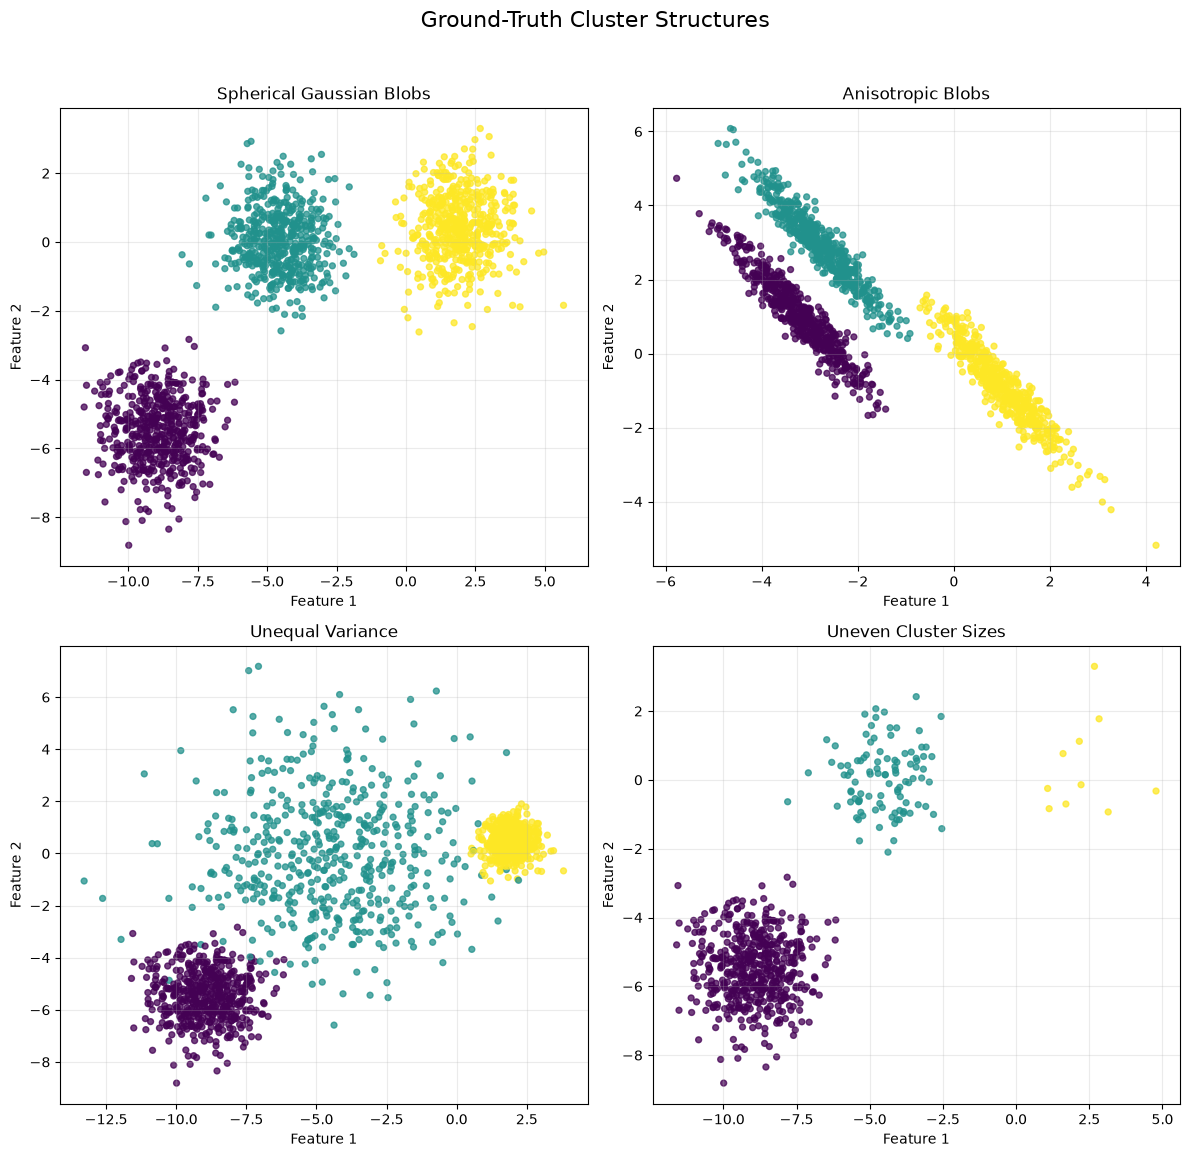

Ground-truth plot saved to: C:\Users\samsa\Documents\Capstone Project\Project\plots\kmeans_assumptions\ground_truth.png


In [9]:
ground_truth_cases = [
    (
        X_spherical,
        y_spherical,
        "Spherical Gaussian Blobs",
    ),
    (
        X_anisotropic,
        y_anisotropic,
        "Anisotropic Blobs",
    ),
    (
        X_varied,
        y_varied,
        "Unequal Variance",
    ),
    (
        X_uneven,
        y_uneven,
        "Uneven Cluster Sizes",
    ),
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12, 12),
)

for axis, (features, labels, title) in zip(
    axes.ravel(),
    ground_truth_cases,
):
    axis.scatter(
        features[:, 0],
        features[:, 1],
        c=labels,
        cmap="viridis",
        s=18,
        alpha=0.75,
    )

    axis.set_title(title)
    axis.set_xlabel("Feature 1")
    axis.set_ylabel("Feature 2")
    axis.grid(alpha=0.25)

fig.suptitle(
    "Ground-Truth Cluster Structures",
    fontsize=16,
    y=0.96,
)

fig.tight_layout(rect=[0, 0, 1, 0.94])

ground_truth_path = PLOTS_DIR / "ground_truth.png"

fig.savefig(
    ground_truth_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Ground-truth plot saved to: {ground_truth_path}")

##### Explanation :
The ground-truth figure demonstrates four different clustering structures.

1. **Spherical blobs:** Compact, separated, and balanced clusters. This is the most suitable structure for K-Means.
2. **Anisotropic blobs:** Elongated clusters with rotated orientations.
3. **Unequal variance:** Clusters have different levels of spread.
4. **Uneven sizes:** One large cluster, one medium cluster, and one very small cluster.

The figure provides the reference structure against which the predicted clusters will be compared.

### Prepare Containers for Model Results

Two empty lists are created:

- `metric_rows` stores one row of evaluation metrics for every fitted model.
- `cluster_size_rows` stores the size and percentage of every predicted cluster.

These lists will later be converted into Pandas DataFrames.

In [10]:
metric_rows = []
cluster_size_rows = []

print("Metric and cluster-size result containers are ready.")

Metric and cluster-size result containers are ready.


##### Explanation :
The result containers are initially empty.

Each clustering experiment will add:

- One model-level metric record
- One cluster-size record for every predicted cluster

This ensures that all experiments are evaluated using the same structure.

### Define the Clustering Evaluation Function

The evaluation function calculates five clustering metrics.

##### Inertia

The total squared distance between observations and their assigned centroids. Lower inertia indicates more compact clusters, but inertia always decreases or remains unchanged when more clusters are added.

##### Silhouette Score

Measures within-cluster cohesion and between-cluster separation. Higher values are generally better.

##### Davies-Bouldin Index

Compares cluster spread with separation between clusters. Lower values are better.

##### Calinski-Harabasz Index

Compares between-cluster dispersion with within-cluster dispersion. Higher values are better.

##### Adjusted Rand Index

Compares the predicted clusters with the known synthetic labels. Values closer to 1 indicate stronger agreement.

The Adjusted Rand Index can be calculated here because the synthetic data have known labels. Real ICU clustering data will generally not have true cluster labels.

In [11]:
def record_clustering_result(
    dataset_name,
    model_name,
    features,
    true_labels,
    predicted_labels,
    inertia=np.nan,
):
    """Calculate and store clustering metrics and cluster sizes."""

    predicted_labels = np.asarray(predicted_labels)
    unique_clusters = np.unique(predicted_labels)

    if len(unique_clusters) >= 2:
        silhouette = silhouette_score(
            features,
            predicted_labels,
        )

        davies_bouldin = davies_bouldin_score(
            features,
            predicted_labels,
        )

        calinski_harabasz = calinski_harabasz_score(
            features,
            predicted_labels,
        )
    else:
        silhouette = np.nan
        davies_bouldin = np.nan
        calinski_harabasz = np.nan

    ari = adjusted_rand_score(
        true_labels,
        predicted_labels,
    )

    metric_rows.append(
        {
            "Dataset": dataset_name,
            "Model": model_name,
            "Clusters": len(unique_clusters),
            "Inertia": inertia,
            "Silhouette": silhouette,
            "Davies_Bouldin": davies_bouldin,
            "Calinski_Harabasz": calinski_harabasz,
            "ARI": ari,
        }
    )

    cluster_labels, cluster_counts = np.unique(
        predicted_labels,
        return_counts=True,
    )

    for cluster_label, count in zip(
        cluster_labels,
        cluster_counts,
    ):
        cluster_size_rows.append(
            {
                "Dataset": dataset_name,
                "Model": model_name,
                "Cluster": int(cluster_label),
                "Count": int(count),
                "Percentage": (
                    100 * count / len(predicted_labels)
                ),
            }
        )

##### Explanation :
The function standardizes the evaluation of every clustering model.

It stores both internal evaluation metrics and the Adjusted Rand Index. It also records the number and percentage of observations assigned to each predicted cluster.

No model has been fitted in this cell, so no numerical output is produced yet.

### Define the Cluster Plotting Function

A reusable plotting function is created to ensure that all cluster visualizations use the same format.

The function displays:

- Observations colored by predicted cluster
- Cluster centroids or component means
- Axis labels
- Plot title
- Background grid

In [12]:
def plot_clusters(
    axis,
    features,
    labels,
    title,
    centers=None,
):
    """Plot clustered observations and optional cluster centers."""

    axis.scatter(
        features[:, 0],
        features[:, 1],
        c=labels,
        cmap="viridis",
        s=18,
        alpha=0.75,
    )

    if centers is not None:
        axis.scatter(
            centers[:, 0],
            centers[:, 1],
            marker="X",
            s=180,
            c="white",
            edgecolor="black",
            linewidth=1.2,
            label="Cluster centers",
        )

        axis.legend(loc="best")

    axis.set_title(title)
    axis.set_xlabel("Feature 1")
    axis.set_ylabel("Feature 2")
    axis.grid(alpha=0.25)

##### Explanation :
This function provides consistent visualization across all K-Means and Gaussian Mixture Model experiments.

For K-Means, the large `X` markers represent cluster centroids.

For Gaussian Mixture Models, the markers represent the estimated component means.

### Fit KMeans Under Assumption Violations

Four K-Means models are fitted.

1. The spherical dataset is intentionally fitted using `k=2`, although it contains three true clusters.
2. The anisotropic dataset is fitted using `k=3`.
3. The unequal-variance dataset is fitted using `k=3`.
4. The uneven-size dataset is fitted using `k=3`.

A fixed random state is used so that the fitted results remain reproducible.

The combined figure is saved as `kmeans_failures.png`.

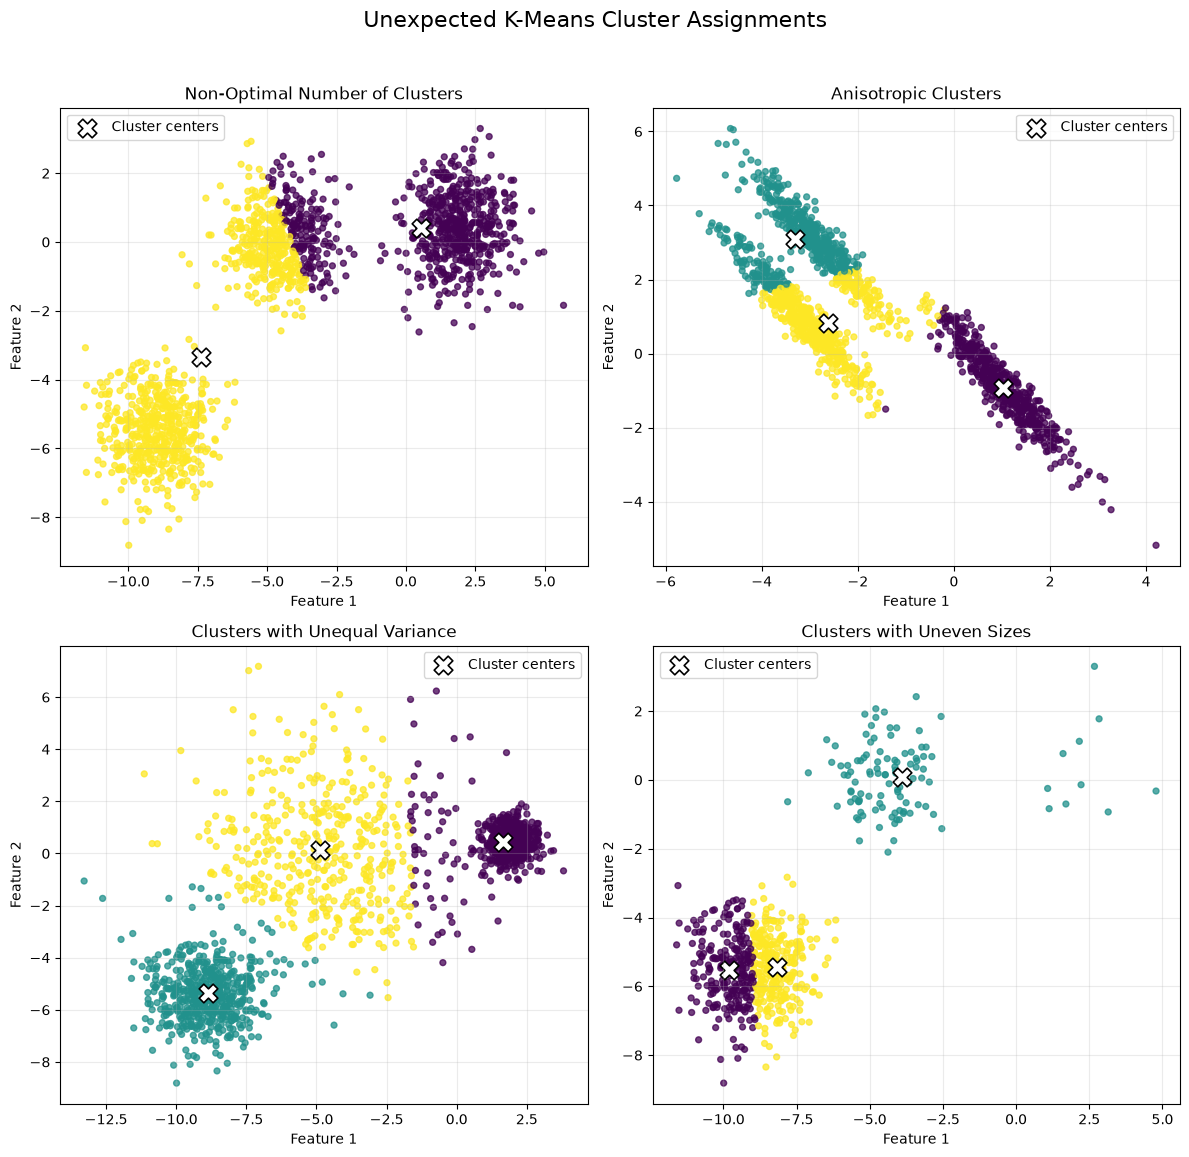

K-Means failure plot saved to: C:\Users\samsa\Documents\Capstone Project\Project\plots\kmeans_assumptions\kmeans_failures.png


In [13]:
common_kmeans_params = {
    "n_init": "auto",
    "random_state": RANDOM_STATE,
}

kmeans_cases = [
    {
        "dataset_name": "Spherical blobs",
        "model_name": "KMeans k=2",
        "features": X_spherical,
        "true_labels": y_spherical,
        "n_clusters": 2,
        "title": "Non-Optimal Number of Clusters",
    },
    {
        "dataset_name": "Anisotropic blobs",
        "model_name": "KMeans k=3",
        "features": X_anisotropic,
        "true_labels": y_anisotropic,
        "n_clusters": 3,
        "title": "Anisotropic Clusters",
    },
    {
        "dataset_name": "Unequal variance",
        "model_name": "KMeans k=3",
        "features": X_varied,
        "true_labels": y_varied,
        "n_clusters": 3,
        "title": "Clusters with Unequal Variance",
    },
    {
        "dataset_name": "Uneven sizes",
        "model_name": "KMeans k=3, n_init=auto",
        "features": X_uneven,
        "true_labels": y_uneven,
        "n_clusters": 3,
        "title": "Clusters with Uneven Sizes",
    },
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12, 12),
)

for axis, case in zip(axes.ravel(), kmeans_cases):
    model = KMeans(
        n_clusters=case["n_clusters"],
        **common_kmeans_params,
    )

    predicted_labels = model.fit_predict(
        case["features"]
    )

    record_clustering_result(
        dataset_name=case["dataset_name"],
        model_name=case["model_name"],
        features=case["features"],
        true_labels=case["true_labels"],
        predicted_labels=predicted_labels,
        inertia=model.inertia_,
    )

    plot_clusters(
        axis=axis,
        features=case["features"],
        labels=predicted_labels,
        title=case["title"],
        centers=model.cluster_centers_,
    )

fig.suptitle(
    "Unexpected K-Means Cluster Assignments",
    fontsize=16,
    y=0.96,
)

fig.tight_layout(rect=[0, 0, 1, 0.94])

kmeans_failures_path = PLOTS_DIR / "kmeans_failures.png"

fig.savefig(
    kmeans_failures_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"K-Means failure plot saved to: {kmeans_failures_path}")

##### Explanation :

The figure demonstrates four important K-Means limitations.

**Incorrect Number of Clusters**

Using `k=2` forces the three natural spherical groups into only two clusters. K-Means cannot independently determine the correct number of clusters.

**Anisotropic Clusters**

The elongated groups are divided according to distance from the centroids rather than their actual rotated geometry.

**Unequal Variance**

The wider cluster influences the centroid assignments differently from the compact cluster. This can cause observations to be assigned according to distance rather than the original generating group.

**Uneven Cluster Sizes**

The large cluster strongly influences the K-Means objective. With only one initialization, the very small cluster may not receive its own centroid and may instead be merged with another group.

### Display and Save the Initial KMeans Metrics

The evaluation metrics for the four difficult K-Means cases are converted into a DataFrame.

A rounded copy is displayed for readability, while the original full-precision values are saved as `kmeans_metrics.csv`.

In [14]:
kmeans_metrics_df = pd.DataFrame(metric_rows)

numeric_columns = [
    "Inertia",
    "Silhouette",
    "Davies_Bouldin",
    "Calinski_Harabasz",
    "ARI",
]

kmeans_metrics_display = kmeans_metrics_df.copy()

kmeans_metrics_display[numeric_columns] = (
    kmeans_metrics_display[numeric_columns].round(4)
)

kmeans_metrics_path = RESULTS_DIR / "kmeans_metrics.csv"

kmeans_metrics_df.to_csv(
    kmeans_metrics_path,
    index=False,
)

display(kmeans_metrics_display)

print(f"K-Means metrics saved to: {kmeans_metrics_path}")

,Dataset,Model,Clusters,Inertia,Silhouette,Davies_Bouldin,Calinski_Harabasz,ARI
0,Spherical blobs,KMeans k=2,2,15064.9416,0.5320,0.6523,2831.4035,0.4574
1,Anisotropic blobs,KMeans k=3,3,1899.3067,0.5100,0.7066,3716.5019,0.6127
2,Unequal variance,KMeans k=3,3,5748.3284,0.6469,0.5689,5451.3198,0.8298
3,Uneven sizes,"KMeans k=3, n_init=auto",3,1293.4259,0.3771,0.9460,1273.9340,0.3821


K-Means metrics saved to: C:\Users\samsa\Documents\Capstone Project\Project\results\kmeans_assumptions\kmeans_metrics.csv


##### Explanation :
Using the same random seed, the uploaded notebook produced approximately the following Adjusted Rand Index values:

- Incorrect `k=2`: `0.4574`
- Anisotropic clusters: `0.6127`
- Unequal variance: `0.8298`
- Uneven cluster sizes with `n_init="auto"`: `0.3821`

The uneven-size dataset produces the weakest agreement with the true labels.

An important observation is that the unequal-variance case can have a relatively strong silhouette score while still failing to perfectly recover the true groups. Therefore, internal clustering metrics should not be interpreted as proof that the clusters are clinically correct.

### Solution 1: Select a More Appropriate Number of Clusters

The spherical dataset contains three true groups.

The previous model intentionally used `k=2`. This experiment changes the number of clusters to `k=3` while keeping the remaining K-Means settings unchanged.

The resulting plot is saved as `solution1.png`.

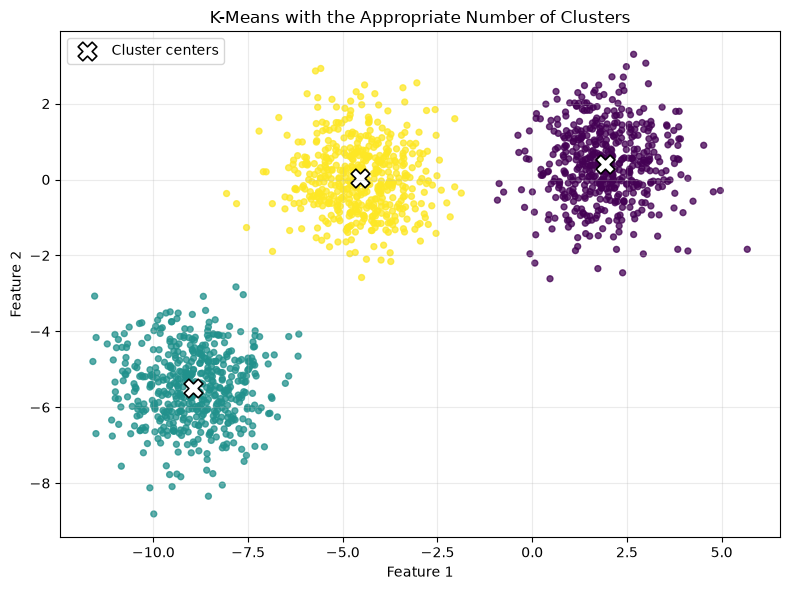

Solution 1 plot saved to: C:\Users\samsa\Documents\Capstone Project\Project\plots\kmeans_assumptions\solution1.png


In [15]:
correct_k_model = KMeans(
    n_clusters=3,
    **common_kmeans_params,
)

correct_k_labels = correct_k_model.fit_predict(
    X_spherical
)

record_clustering_result(
    dataset_name="Spherical blobs",
    model_name="KMeans k=3",
    features=X_spherical,
    true_labels=y_spherical,
    predicted_labels=correct_k_labels,
    inertia=correct_k_model.inertia_,
)

fig, axis = plt.subplots(figsize=(8, 6))

plot_clusters(
    axis=axis,
    features=X_spherical,
    labels=correct_k_labels,
    title="K-Means with the Appropriate Number of Clusters",
    centers=correct_k_model.cluster_centers_,
)

fig.tight_layout()

correct_k_path = PLOTS_DIR / "solution1.png"

fig.savefig(
    correct_k_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Solution 1 plot saved to: {correct_k_path}")

##### Explanation :
Using `k=3` allows K-Means to recover the three compact spherical groups correctly.

In the uploaded notebook, this model produced:

- Adjusted Rand Index: `1.0000`
- Silhouette score: approximately `0.7333`
- Davies-Bouldin index: approximately `0.3645`

This demonstrates that selecting an appropriate number of clusters can substantially improve the model when the data already satisfy the geometric assumptions of K-Means.

### Solution 2: Use Multiple Centroid Initializations

K-Means can converge to a local minimum depending on the initial centroid locations.

Setting `n_init=10` instructs the model to:

1. Perform ten different centroid initializations.
2. Fit K-Means for each initialization.
3. Retain the solution with the lowest inertia.

This experiment applies ten initializations to the uneven-size dataset.

The resulting plot is saved as `solution2.png`.

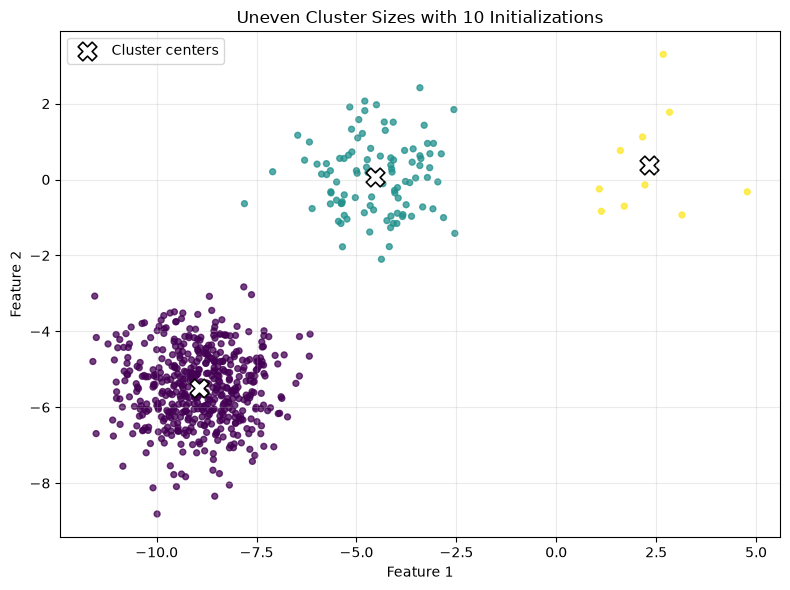

Solution 2 plot saved to: C:\Users\samsa\Documents\Capstone Project\Project\plots\kmeans_assumptions\solution2.png


In [16]:
multi_init_model = KMeans(
    n_clusters=3,
    n_init=10,
    random_state=RANDOM_STATE,
)

multi_init_labels = multi_init_model.fit_predict(
    X_uneven
)

record_clustering_result(
    dataset_name="Uneven sizes",
    model_name="KMeans k=3, n_init=10",
    features=X_uneven,
    true_labels=y_uneven,
    predicted_labels=multi_init_labels,
    inertia=multi_init_model.inertia_,
)

fig, axis = plt.subplots(figsize=(8, 6))

plot_clusters(
    axis=axis,
    features=X_uneven,
    labels=multi_init_labels,
    title="Uneven Cluster Sizes with 10 Initializations",
    centers=multi_init_model.cluster_centers_,
)

fig.tight_layout()

multi_init_path = PLOTS_DIR / "solution2.png"

fig.savefig(
    multi_init_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Solution 2 plot saved to: {multi_init_path}")

##### Explanation :
In the uploaded notebook, increasing `n_init` from `"auto"` to `10` improved the uneven-size clustering substantially.

The model produced:

- Adjusted Rand Index: `1.0000`
- Inertia reduced from approximately `1293.43` to `1203.60`
- Predicted cluster sizes of 500, 100, and 10

This means one of the ten initialization attempts successfully placed a centroid near the very small cluster.

However, multiple initialization only improves the optimization process. It does not guarantee that K-Means will always handle unequal cluster sizes correctly in other datasets.

### Solution 3: Use Gaussian Mixture Models

K-Means represents each cluster using a centroid and implicitly favors approximately spherical groups.

A Gaussian Mixture Model can estimate a separate covariance matrix for each component.

Using `covariance_type="full"` allows each component to have its own:

- Size
- Variance
- Orientation
- Elliptical shape

Gaussian Mixture Models are applied to:

1. The anisotropic dataset
2. The unequal-variance dataset

The resulting comparison is saved as `solution3.png`.

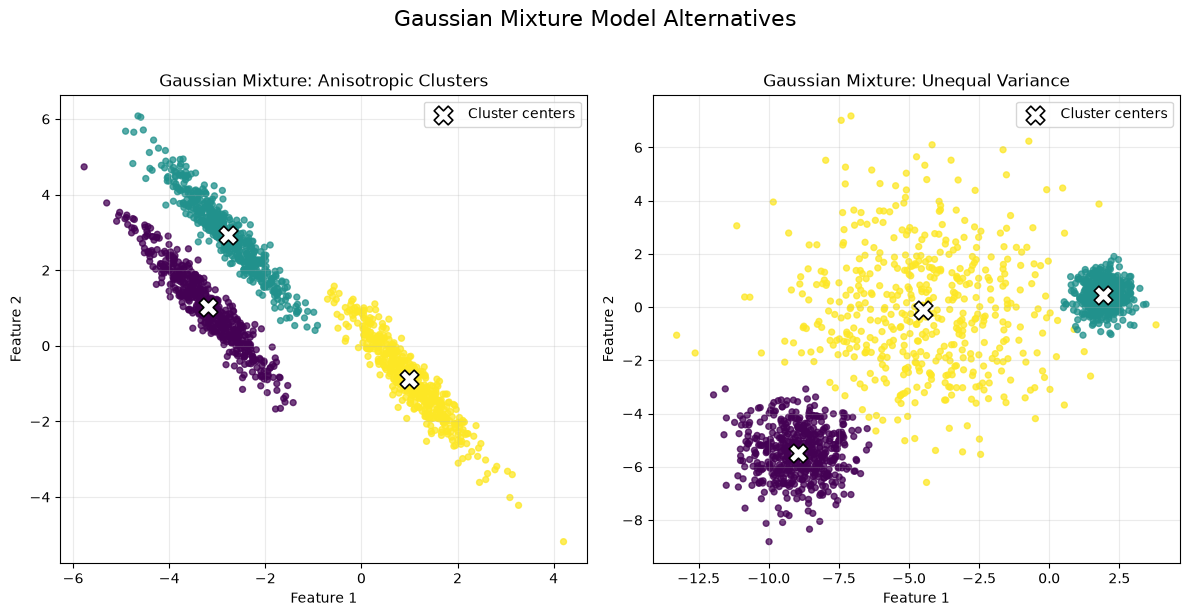

Solution 3 plot saved to: C:\Users\samsa\Documents\Capstone Project\Project\plots\kmeans_assumptions\solution3.png


In [17]:
gmm_cases = [
    {
        "dataset_name": "Anisotropic blobs",
        "features": X_anisotropic,
        "true_labels": y_anisotropic,
        "title": "Gaussian Mixture: Anisotropic Clusters",
    },
    {
        "dataset_name": "Unequal variance",
        "features": X_varied,
        "true_labels": y_varied,
        "title": "Gaussian Mixture: Unequal Variance",
    },
]

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 6),
)

for axis, case in zip(axes, gmm_cases):
    gmm_model = GaussianMixture(
        n_components=3,
        covariance_type="full",
        n_init=10,
        random_state=RANDOM_STATE,
    )

    gmm_labels = gmm_model.fit_predict(
        case["features"]
    )

    record_clustering_result(
        dataset_name=case["dataset_name"],
        model_name="GaussianMixture k=3",
        features=case["features"],
        true_labels=case["true_labels"],
        predicted_labels=gmm_labels,
    )

    plot_clusters(
        axis=axis,
        features=case["features"],
        labels=gmm_labels,
        title=case["title"],
        centers=gmm_model.means_,
    )

fig.suptitle(
    "Gaussian Mixture Model Alternatives",
    fontsize=16,
    y=1.02,
)

fig.tight_layout()

gmm_path = PLOTS_DIR / "solution3.png"

fig.savefig(
    gmm_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Solution 3 plot saved to: {gmm_path}")

##### Explanation :
The Gaussian Mixture Models recover the non-spherical structures more accurately than K-Means.

In the uploaded notebook, the results were approximately:

**Anisotropic Dataset**

- K-Means Adjusted Rand Index: `0.6127`
- Gaussian Mixture Adjusted Rand Index: `1.0000`

**Unequal-Variance Dataset**

- K-Means Adjusted Rand Index: `0.8298`
- Gaussian Mixture Adjusted Rand Index: `0.9664`

The Gaussian Mixture Model performs better because it models component covariance instead of relying only on Euclidean distance from a centroid.

The anisotropic Gaussian Mixture result also demonstrates that a lower silhouette score does not necessarily indicate worse recovery of the true groups. Different metrics evaluate different properties of a clustering solution.

### Save the Complete Model Comparison

All model-level results are combined into a single table.

A second table stores the number and percentage of observations assigned to each predicted cluster.

The following result files are created:

- `model_metrics.csv`
- `cluster_sizes.csv`
- `model_metrics.txt`

In [18]:
# Complete model-level metrics
all_metrics_df = pd.DataFrame(metric_rows)
all_metrics_display = all_metrics_df.copy()

all_metrics_display[numeric_columns] = (
    all_metrics_display[numeric_columns].round(4)
)

# Complete cluster-size results
cluster_sizes_df = pd.DataFrame(cluster_size_rows)
cluster_sizes_display = cluster_sizes_df.copy()

cluster_sizes_display["Percentage"] = (
    cluster_sizes_display["Percentage"].round(2)
)

# Output paths
all_metrics_path = RESULTS_DIR / "model_metrics.csv"
cluster_sizes_path = RESULTS_DIR / "cluster_sizes.csv"
metrics_text_path = RESULTS_DIR / "model_metrics.txt"

# Save results
all_metrics_df.to_csv(
    all_metrics_path,
    index=False,
)

cluster_sizes_df.to_csv(
    cluster_sizes_path,
    index=False,
)

metrics_text_path.write_text(
    all_metrics_display.to_string(index=False),
    encoding="utf-8",
)

print("=" * 80)
print("COMPLETE MODEL COMPARISON")
print("=" * 80)

display(all_metrics_display)

print("=" * 80)
print("CLUSTER SIZE COMPARISON")
print("=" * 80)

display(cluster_sizes_display)

print("=" * 80)
print("SAVED RESULT FILES")
print("=" * 80)
print(f"Model metrics : {all_metrics_path}")
print(f"Cluster sizes : {cluster_sizes_path}")
print(f"Text results  : {metrics_text_path}")
print("=" * 80)

COMPLETE MODEL COMPARISON


,Dataset,Model,Clusters,Inertia,Silhouette,Davies_Bouldin,Calinski_Harabasz,ARI
0,Spherical blobs,KMeans k=2,2,15064.9416,0.5320,0.6523,2831.4035,0.4574
1,Anisotropic blobs,KMeans k=3,3,1899.3067,0.5100,0.7066,3716.5019,0.6127
2,Unequal variance,KMeans k=3,3,5748.3284,0.6469,0.5689,5451.3198,0.8298
3,Uneven sizes,"KMeans k=3, n_init=auto",3,1293.4259,0.3771,0.9460,1273.9340,0.3821
4,Spherical blobs,KMeans k=3,3,2862.7319,0.7333,0.3645,10633.8689,1.0000
5,Uneven sizes,"KMeans k=3, n_init=10",3,1203.6015,0.7449,0.3839,1391.6574,1.0000
6,Anisotropic blobs,GaussianMixture k=3,3,NaN,0.4769,0.8576,2807.6875,1.0000
7,Unequal variance,GaussianMixture k=3,3,NaN,0.6193,0.5850,4552.8809,0.9664


CLUSTER SIZE COMPARISON


,Dataset,Model,Cluster,Count,Percentage
0,Spherical blobs,KMeans k=2,0,670,44.67
1,Spherical blobs,KMeans k=2,1,830,55.33
2,Anisotropic blobs,KMeans k=3,0,489,32.60
3,Anisotropic blobs,KMeans k=3,1,503,33.53
4,Anisotropic blobs,KMeans k=3,2,508,33.87
5,Unequal variance,KMeans k=3,0,563,37.53
6,Unequal variance,KMeans k=3,1,529,35.27
7,Unequal variance,KMeans k=3,2,408,27.20
8,Uneven sizes,"KMeans k=3, n_init=auto",0,240,39.34
9,Uneven sizes,"KMeans k=3, n_init=auto",1,110,18.03


SAVED RESULT FILES
Model metrics : C:\Users\samsa\Documents\Capstone Project\Project\results\kmeans_assumptions\model_metrics.csv
Cluster sizes : C:\Users\samsa\Documents\Capstone Project\Project\results\kmeans_assumptions\cluster_sizes.csv
Text results  : C:\Users\samsa\Documents\Capstone Project\Project\results\kmeans_assumptions\model_metrics.txt


##### Explanation :
The complete model comparison contains eight fitted models:

1. K-Means with `k=2` on spherical data
2. K-Means on anisotropic data
3. K-Means on unequal-variance data
4. K-Means on uneven-size data with `n_init="auto"`
5. K-Means with the corrected `k=3`
6. K-Means on uneven-size data with `n_init=10`
7. Gaussian Mixture Model on anisotropic data
8. Gaussian Mixture Model on unequal-variance data

The cluster-size table is especially important for identifying very small or highly dominant clusters. In an ICU project, this table can reveal whether a clinically important rare patient subgroup has been lost inside a larger cluster.

### Save a Human-Readable Summary

In [19]:
summary_lines = [
    "K-Means Assumptions and Model Fit Tutorial",
    "",
    "Main conclusions:",
    "1. K-Means requires the analyst to specify the number of clusters.",
    "2. K-Means works best for compact and approximately spherical clusters.",
    "3. K-Means performs best when clusters have similar variance.",
    "4. Strongly unequal cluster sizes can hide small but meaningful groups.",
    "5. Multiple initializations can improve the optimization result.",
    "6. Multiple initializations do not remove all geometric limitations.",
    "7. Gaussian Mixture Models can represent elliptical clusters.",
    "8. Gaussian Mixture Models can represent clusters with different covariance structures.",
]

summary_path = RESULTS_DIR / "summary.txt"

summary_path.write_text(
    "\n".join(summary_lines),
    encoding="utf-8",
)

print("=" * 80)
print("GENERATED PLOT FILES")
print("=" * 80)

for plot_path in sorted(PLOTS_DIR.glob("*.png")):
    print(f"- {plot_path.name}")

print("\n" + "=" * 80)
print("GENERATED RESULT FILES")
print("=" * 80)

for result_path in sorted(RESULTS_DIR.iterdir()):
    if result_path.is_file():
        print(f"- {result_path.name}")

print("\n" + "=" * 80)
print(f"Summary saved to: {summary_path}")
print("=" * 80)

GENERATED PLOT FILES
- ground_truth.png
- kmeans_failures.png
- solution1.png
- solution2.png
- solution3.png

GENERATED RESULT FILES
- cluster_sizes.csv
- data_summary.csv
- kmeans_metrics.csv
- model_metrics.csv
- model_metrics.txt
- summary.txt

Summary saved to: C:\Users\samsa\Documents\Capstone Project\Project\results\kmeans_assumptions\summary.txt


### Final Conclusions and Relevance to ICU Patient Clustering

K-Means is most reliable when clusters are:

- Compact
- Well separated
- Approximately spherical
- Similar in variance
- Not extremely different in sample size

The experiments demonstrate several risks that are directly relevant to clustering ICU patients.

##### Number of Clusters

An incorrect value of `k` can merge distinct clinical phenotypes or divide one phenotype into multiple artificial groups.

##### Non-Spherical Patient Profiles

Clinical variables are often correlated. As a result, patient subgroups may form elongated or irregular structures that K-Means cannot represent accurately.

##### Unequal Variance

Some patient phenotypes may be clinically homogeneous, while other phenotypes may contain highly variable patients. K-Means may handle these groups inconsistently.

##### Unequal Cluster Sizes

A rare but clinically important high-risk phenotype may contain far fewer patients than the general ICU population. K-Means may absorb this subgroup into a larger cluster.

##### Model Initialization

Testing multiple centroid initializations reduces the risk of retaining a poor local solution. However, it does not eliminate the fundamental geometric assumptions of K-Means.

##### Evaluation

A low inertia or high silhouette score alone does not establish that the discovered clusters are clinically meaningful.

The final ICU clustering analysis should therefore include:

- Multiple candidate values of `k`
- Multiple random seeds
- Multiple centroid initializations
- Internal clustering metrics
- Cluster-size analysis
- Stability analysis
- Clinical interpretation
- Comparison with alternative clustering methods
- Careful examination of rare patient subgroups

The discovered groups should be treated as model-dependent patient partitions until their clinical relevance, reproducibility, and outcome differences are properly evaluated.